In [1]:
from ultralytics.models.sam import SAM
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import cv2
from optimum.intel import OVStableDiffusionInpaintPipeline

Multiple distributions found for package optimum. Picked distribution: optimum
c:\Users\zeyad\miniconda3\envs\multimodal\Lib\site-packages\torch\amp\autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


In [2]:
img_path = "../data/me_holding_cat.png"
img_out = "../data/me_holding_cat_inpainted.png"

orig_img = Image.open(img_path)
inpainted_img = Image.open(img_out)

seg_model = SAM("mobile_sam.pt")


0: 1024x1024 1 0, 2324.0ms
Speed: 99.0ms preprocess, 2324.0ms inference, 34.4ms postprocess per image at shape (1, 3, 1024, 1024)


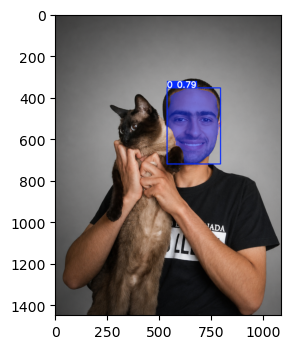

In [3]:
bbox = [501.4826,  370.8253,  756.8513,  750]

segmentation_results = seg_model(orig_img, bboxes=[bbox])[0]

masks = segmentation_results.masks.data

plt.subplot(121)
plt.imshow(segmentation_results.plot()[:, :, ::-1])
# plt.axis("off")

plt.subplot(122)
plt.imshow(masks[0].numpy())
plt.axis("off")

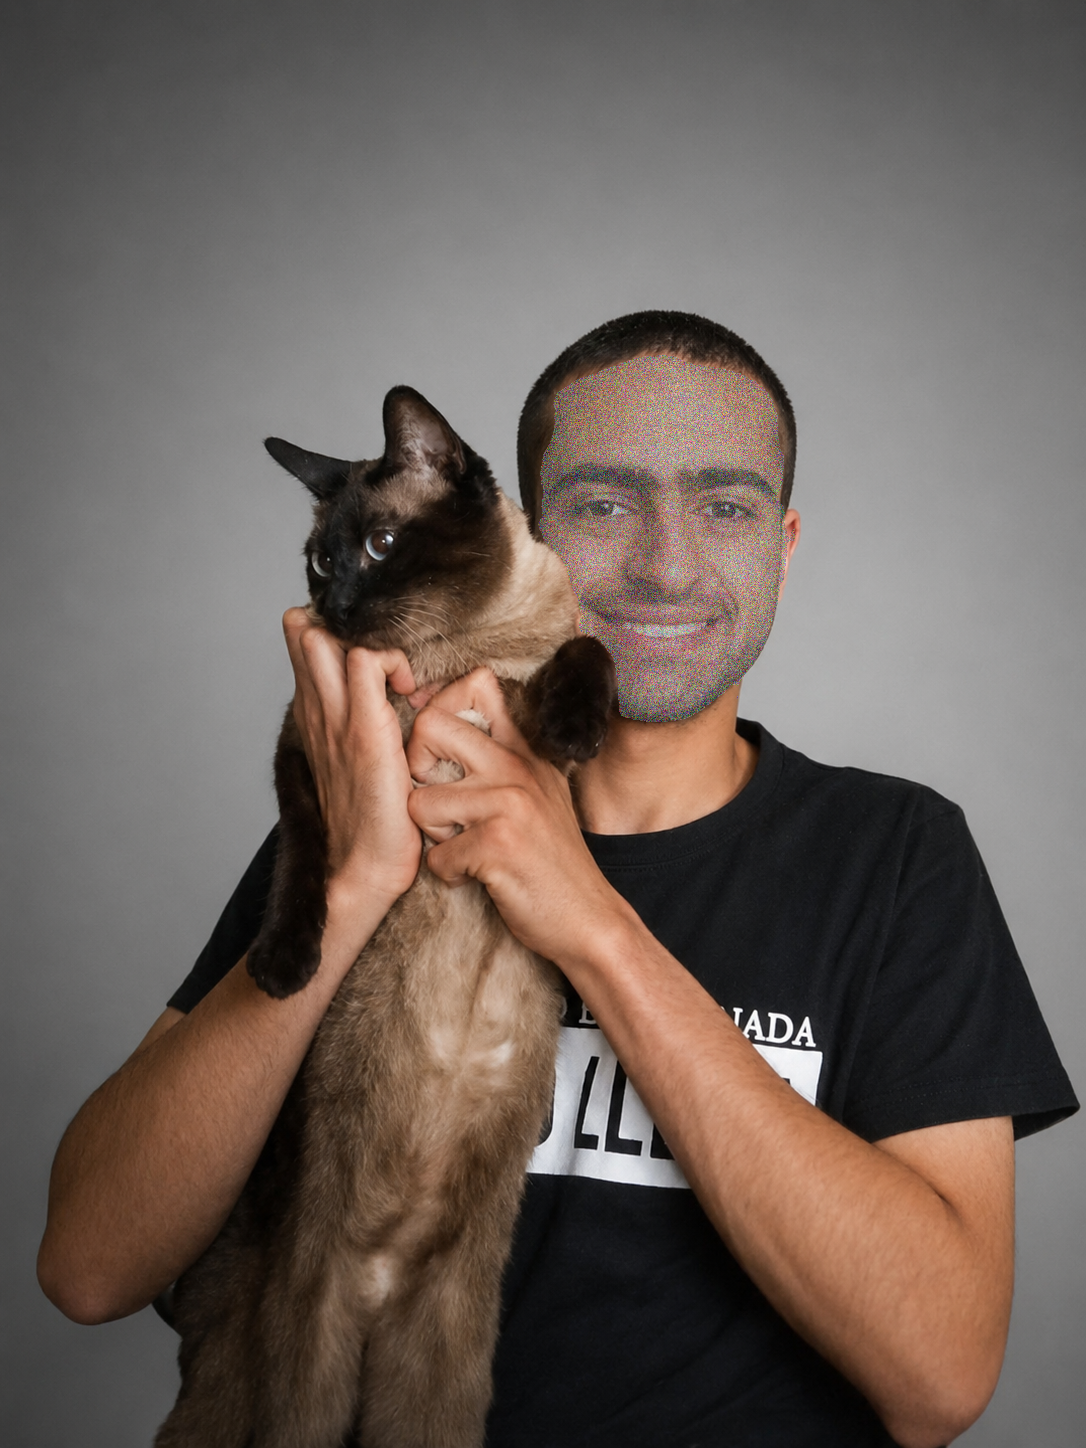

In [43]:
def apply_slide_noise(img, sam_mask_tensor, strength, show_mask_overlay=False):
    img_arr = np.array(img).astype(float)
    mask_arr = sam_mask_tensor.detach().cpu().numpy().astype(float)

    if mask_arr.ndim == 3:
        mask_arr = mask_arr[0]

    mask_img = Image.fromarray((mask_arr * 255).astype(np.uint8)).resize(img.size)
    mask_arr = np.array(mask_img).astype(float) / 255.0

    noise = np.random.normal(127.5, 60.0, img_arr.shape)
    noise = np.clip(noise, 0, 255)

    noised_target = (img_arr * (1.0 - strength)) + (noise * strength)

    mask_arr_3d = np.expand_dims(mask_arr, axis=2)
    final_arr = (noised_target * mask_arr_3d) + (img_arr * (1.0 - mask_arr_3d))

    if show_mask_overlay:
        red_overlay = np.zeros_like(final_arr)
        red_overlay[..., 0] = 255.0
        final_arr = np.where(mask_arr_3d > 0.5, (final_arr * 0.7) + (red_overlay * 0.3), final_arr)

    # Convert back to uint8 PIL Image
    final_img = Image.fromarray(np.clip(final_arr, 0, 255).astype(np.uint8))
    final_img = cv2.resize(np.array(final_img), (orig_img.size[0], orig_img.size[1]))
    final_img = Image.fromarray(final_img)
    return final_img


result_img = apply_slide_noise(orig_img, masks[0], strength=0.5, show_mask_overlay=False)
result_img

In [4]:
# diffuser_model = OVStableDiffusionInpaintPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-inpainting")
# diffuser_model.save_pretrained("../checkpoints/sd15_inpaint_openvino")

diffuser_model = OVStableDiffusionInpaintPipeline.from_pretrained(
    "../checkpoints/sd15_inpaint_openvino", 
    compile=False  # Good practice to disable compile before modifying components
)

diffuser_model.safety_checker = None
diffuser_model.compile()

In [5]:
mask_img = Image.fromarray((masks[0].numpy() * 255).astype(np.uint8))
prompt = "hyperrealistic portrait of an evil vampire, pale skin, glowing red eyes, sharp fangs, cinematic lighting, highly detailed, 8k, masterpiece, intricate textures"

  0%|          | 0/4 [00:00<?, ?it/s]

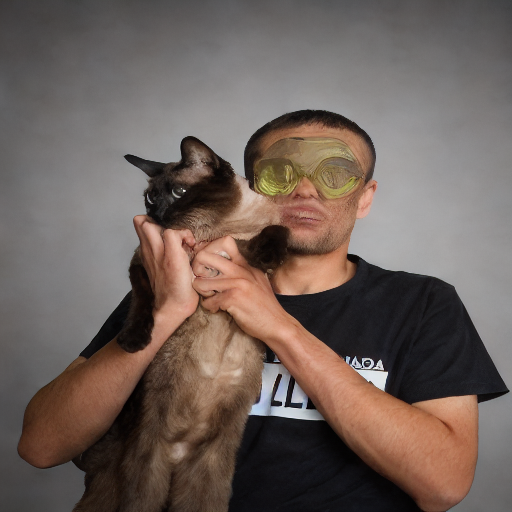

In [9]:
result = diffuser_model(
    prompt=prompt,
    image=orig_img,
    mask_image=mask_img,
    strength=1,
    guidance_scale=1,
    num_inference_steps=4
)

result.images[0]

  0%|          | 0/2 [00:00<?, ?it/s]

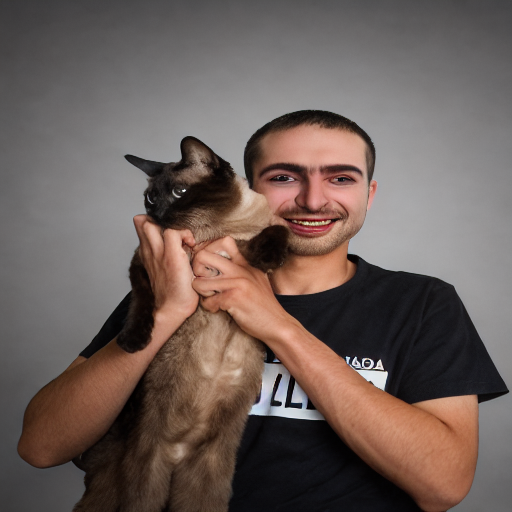

In [8]:
result = diffuser_model(
    prompt=prompt,
    image=orig_img,
    mask_image=mask_img,
    strength=0.5,
    guidance_scale=10,
    num_inference_steps=4
)

result.images[0]

  0%|          | 0/9 [00:00<?, ?it/s]

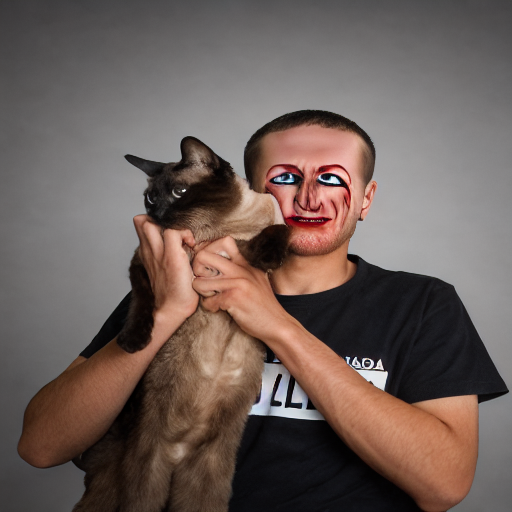

In [10]:
result = diffuser_model(
    prompt=prompt,
    image=orig_img,
    mask_image=mask_img,
    strength=0.7,
    guidance_scale=10,
    num_inference_steps=14
)

result.images[0]

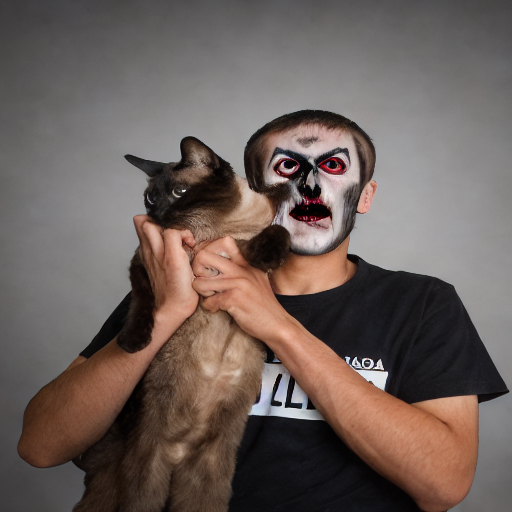

In [ ]:
result = diffuser_model(
    prompt=prompt,
    image=orig_img,
    mask_image=mask_img,
    strength=1,
    guidance_scale=10,
    num_inference_steps=6
)

result.images[0]

  0%|          | 0/16 [00:00<?, ?it/s]

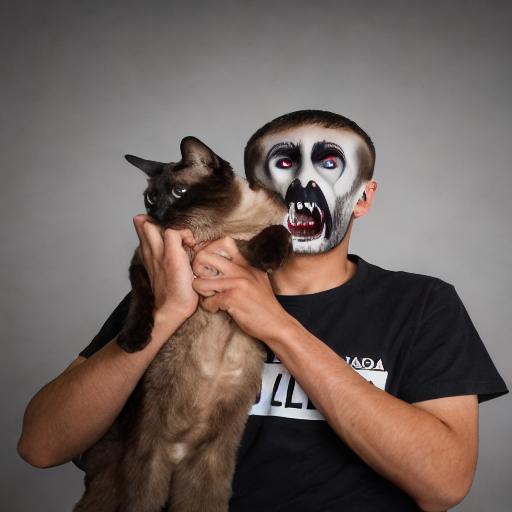

In [11]:
result = diffuser_model(
    prompt=prompt,
    image=orig_img,
    mask_image=mask_img,
    strength=1,
    guidance_scale=10,
    num_inference_steps=16
)

result.images[0]